<a href="https://colab.research.google.com/github/darint521-tech/Project/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Introduction**

In this project, we perform an exploratory data analysis (EDA) to investigate the relationship between temperature and electricity demand in New York. The datasets consist of time-series measurements of ambient temperature (°C) and electricity demand (MW). These variables are continuous and are expected to exhibit a relationship due to the increased use of cooling systems during periods of high temperature.

We hypothesize that electricity demand will increase as temperature rises, reflecting higher energy consumption from air conditioning and other cooling technologies. Through statistical analysis and visualization, we aim to quantify this relationship and assess the strength of the dependence between the two variables.

In [ ]:
import math
import numpy as np
import pandas as pd
import statistics as stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import hashlib

This data set was found on Kaggle, and displays the date, time, and amount of energy (MW) that the PJM grid on the East Coast of the United States consumed per hour. The data was collected from the end of 2002 to the beginning of 2018.

In [ ]:
energy_demand_df = pd.read_csv("PJME_hourly.csv")
energy_demand_df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


This dataset was also found on Kaggle, and displays the temperature in degrees celsius in New York as time passes. There is one data point per hour. The data was collected from the beginning of October, 2012 to the end of November, 2017.

In [ ]:
weather_df = pd.read_csv("temperature.csv")
weather_ny = weather_df[["datetime", "New York"]].copy()
weather_ny["New York"] = weather_ny["New York"] - 273.15
weather_ny["datetime"] = pd.to_datetime(weather_ny["datetime"])
weather_ny.head()

,datetime,New York
0,2012-10-01 12:00:00,NaN
1,2012-10-01 13:00:00,15.070000
2,2012-10-01 14:00:00,15.097676
3,2012-10-01 15:00:00,15.176940
4,2012-10-01 16:00:00,15.256203


## **Summary Statistics**

**Central Tendency: Mean and Median**

In [ ]:
energy_demand_df = pd.read_csv("PJME_hourly.csv")
weather_df = pd.read_csv("temperature.csv")
demand = energy_demand_df["PJME_MW"].dropna()
temp = weather_df["New York"].dropna()

demand_mean = np.mean(demand)
demand_median = np.median(demand)
temp_mean = np.mean(temp)
temp_median = np.median(temp)

print("Demand Mean:", demand_mean)
print("Demand Median:", demand_median)
print("Temperature Mean:", temp_mean)
print("Temperature Median:", temp_median)

Demand Mean: 32080.222830648156
Demand Median: 31421.0
Temperature Mean: 285.40040555825885
Temperature Median: 285.87


**Measures of Variability: Standard Deviation, Interquartile Range, and Coefficient of Variation**

In [ ]:
demand_std = np.std(demand, ddof=1)
demand_iqr = np.percentile(demand, 75) - np.percentile(demand,25)
demand_cv = demand_std / np.mean(demand)

temp_std = np.std(temp, ddof=1)
temp_iqr = np.percentile(temp,75) - np.percentile(temp,25)
temp_cv = temp_std / np.mean(temp)

print("Demand STD:", demand_std)
print("Demand IQR:", demand_iqr)
print("Demand CV:", demand_cv)
print("Temperature STD:", temp_std)
print("Temperature IQR:", temp_iqr)
print("Temperature CV:", temp_cv)

Demand STD: 6464.012166412723
Demand IQR: 8077.0
Demand CV: 0.20149523899931474
Temperature STD: 10.22093182953639
Temperature IQR: 16.389999999999986
Temperature CV: 0.035812604433913424


The electricity demand dataset appears more variable and slightly right-skewed because its mean (32080.22 MW) is higher than its median (31421.0 MW). This suggests there are high-demand values pulling the average upward. All three measures of variability show that demand fluctuates over time. In contrast, the temperature dataset is more stable and roughly symmetric since its mean (285.40) and median (285.87) are very close. Its coefficient of variation (0.0358) is much smaller, indicating far less relative variability than electricity demand. For electricity demand, the median is the better measure of central tendency and the IQR is the better measure of variability because they are less affected by skewness and extreme values. For temperature, the mean is the better central tendency measure and the standard deviation is the better variability measure because the data appear more symmetric.

**New Variable:** $T_C = T_K - 273.15$

In [ ]:
temp_c = weather_df["New York"] - 273.15

temp_c_mean = np.mean(temp_c)      # central tendency
temp_c_std = np.std(temp_c, ddof=1)  # variability

print("Temperature (C) mean:", temp_c_mean)
print("Temperature (C) std:", temp_c_std)

Temperature (C) mean: 12.250405558258839
Temperature (C) std: 10.220931829536312


The numerical summaries for this new variable can be obtained from the old summaries because this is a linear transformation. Since
$T_C =T_K − 273.15$, the mean in Celsius is just the mean in Kelvin minus 273.15, while the standard deviation stays the same because subtracting a constant shifts the data but does not change its spread. So for this variable, the summaries can be converted from the earlier ones.


## **Visualizations**

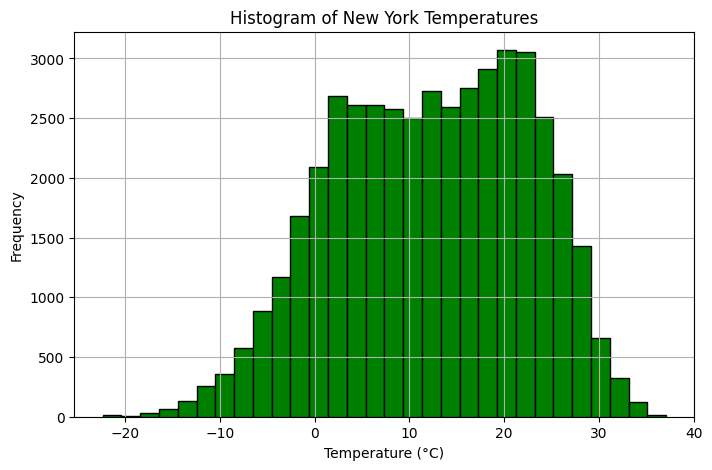

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(weather_ny["New York"], bins=30, color="green", edgecolor="black")
plt.title("Histogram of New York Temperatures")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

The histogram displays the frequency distribution of daily temperatures in degrees celsius in New York. There is a data point for every hour of everyday from the beginning of October, 2012 to the end of November, 2017. Most days fall within a moderate temperature range, indicating that extreme hot or cold days are relatively rare. The shape of the histogram suggests a slight skew toward higher temperatures, reflecting warmer periods during the year. Peaks in the histogram indicate the most common temperature ranges experienced, while the tails show less frequent, extreme temperature events. Overall, this plot helps us understand the variability and central tendency of New York’s daily temperatures over the recorded period.

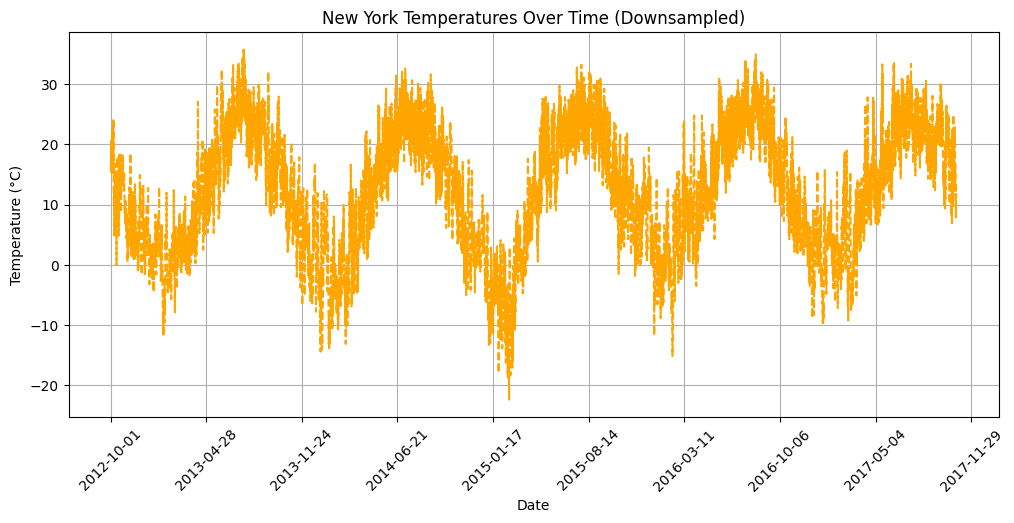

In [ ]:
weather_ny["datetime"] = pd.to_datetime(weather_ny["datetime"])
plot_dates = weather_ny["datetime"][::10]
plot_temps = weather_ny["New York"][::10]
plt.figure(figsize=(12,5))
plt.plot(plot_dates, plot_temps, color="orange", linestyle="--")
plt.title("New York Temperatures Over Time (Downsampled)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
num_ticks = 10
tick_indices = np.linspace(0, len(plot_dates)-1, num_ticks, dtype=int)
plt.xticks(plot_dates.iloc[tick_indices],
           [d.strftime("%Y-%m-%d") for d in plot_dates.iloc[tick_indices]],
           rotation=45)
plt.show()

This line plot shows the trend of daily temperatures in New York over the recorded period. By downsampling the data, we can clearly see seasonal patterns, with higher temperatures in the summer months and lower temperatures in the winter months. The plot also highlights variability from day to day, including occasional spikes or dips that may correspond to unusual weather events. Overall, this visualization provides insight into both the long-term trends and short-term fluctuations in New York’s daily temperatures, making it easier to understand patterns over time.

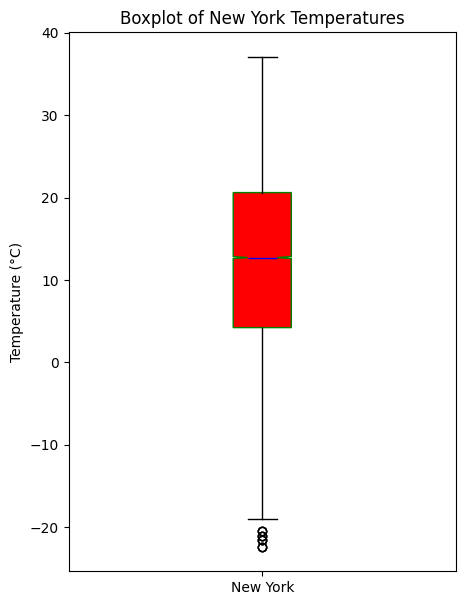

In [ ]:
temps_ny = weather_ny["New York"].dropna()
plt.figure(figsize=(5,7))
plt.boxplot(temps_ny.values,notch=True, patch_artist=True, boxprops=dict(facecolor="red", color="green"), medianprops=dict(color="blue"))
plt.title("Boxplot of New York Temperatures")
plt.ylabel("Temperature (°C)")
plt.xticks([1], ["New York"])
plt.show()

The boxplot illustrates the distribution of daily temperatures in New York. The central line represents the median temperature, showing the midpoint of the dataset, while the box captures the interquartile range, which contains the middle 50% of the data. The whiskers extend to show the typical range of temperatures, and any points outside the whiskers are considered outliers, representing unusually hot or cold days. Notably, the whisker on the colder end is longer than the warmer end, indicating that extremely low temperatures occur more frequently or vary more than extremely high temperatures. This visualization makes it easy to see the spread, central tendency, and extremes of New York’s temperatures, highlighting both the typical daily conditions and the rare temperature events.

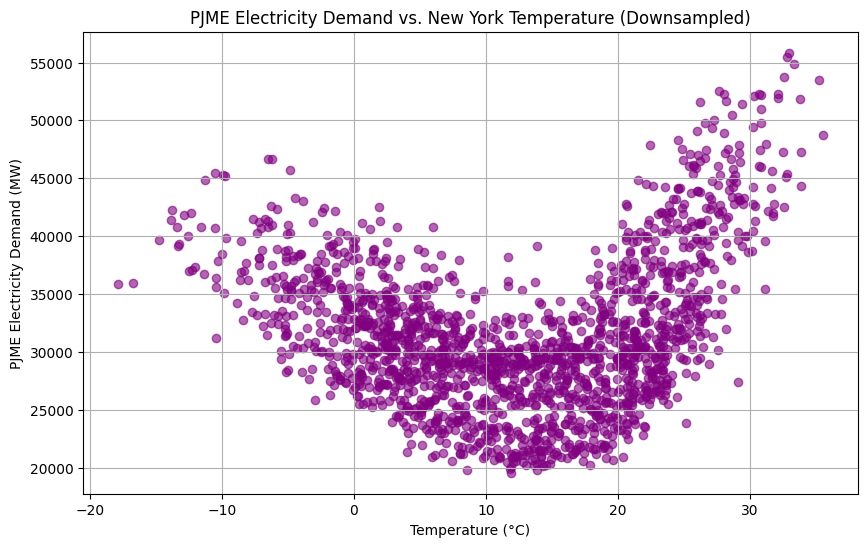

In [ ]:
energy_demand_df.columns = energy_demand_df.columns.str.strip().str.lower()
weather_ny.columns = weather_ny.columns.str.strip().str.lower()
energy_demand_df['datetime'] = pd.to_datetime(energy_demand_df['datetime'])
weather_ny['datetime'] = pd.to_datetime(weather_ny['datetime'])
merged_df = pd.merge(energy_demand_df, weather_ny, on='datetime', how='inner')

data_sample = merged_df.iloc[::25]
plt.figure(figsize=(10,6))
plt.scatter(data_sample['new york'], data_sample['pjme_mw'],
            color='purple', marker='o', alpha=0.6)
plt.title("PJME Electricity Demand vs. New York Temperature (Downsampled)")
plt.xlabel("Temperature (°C)")
plt.ylabel("PJME Electricity Demand (MW)")
plt.grid(True)
plt.show()

The scatter plot reveals a generally U-shaped relationship between temperature and electricity demand in the PJME region. Electricity demand tends to be lowest at moderate temperatures and increases as temperatures move toward either extreme. At lower temperatures, demand rises due to heating needs, while at higher temperatures, demand increases because of air conditioning usage. Although the trend is not perfectly smooth—due to other influencing factors such as time of day, seasonal patterns, and human behavior—the overall pattern clearly shows that temperature is a major driver of electricity consumption. This suggests that energy providers must prepare for higher demand during both very cold and very hot periods, making temperature an important variable in forecasting and managing energy loads.

## **Independence**

Using code to determine if the values are independent or dependent through covariance. The larger the absolute value of the outcome is, the larger the covariance. A larger absolute value of covariance means that the values are likely dependent. If the value is almost equal to zero that shows a low covariance and likely means the values are independent.


In [ ]:
energy_demand_df = pd.read_csv("PJME_hourly.csv")
weather_df = pd.read_csv("temperature.csv")

energy_demand_df['Datetime'] = pd.to_datetime(energy_demand_df['Datetime'])
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])

energy_demand_df = energy_demand_df.sort_values(by='Datetime')
weather_df = weather_df.sort_values(by='datetime')

merged = pd.merge(energy_demand_df, weather_df, left_on='Datetime', right_on='datetime', how='inner')
merged = merged.dropna()

temp = merged["New York"].dropna()
demand = merged["PJME_MW"].dropna()
correlation = np.corrcoef(temp, demand)[0,1]
correlation = round(correlation, 3)
print("Correlation Coefficient:", correlation)
covariance = np.cov(temp, demand)[0,1]
covariance = round(abs(covariance), 0)
print("Covariance:", int(covariance))

Correlation Coefficient: 0.126
Covariance: 8151


The correlation coefficient result is 0.126, close to zero. This indicates a weak linear relationship between the two variables. This is likley because the true relation is not linear. When it is colder people use energy to heat, when its hot people use energy to cool. This results in a U like shape in the data. The results are not linear, which means the correlation coefficient will be close to zero. Even though there is a strong correlation between temperature and energy use, because that correlation is U shaped, it doesn't show up in the correlation coefficient test. The values for energy increase as the temperature moves away from a comfortable range (~15 degrees Celcius).

## **Distributions**

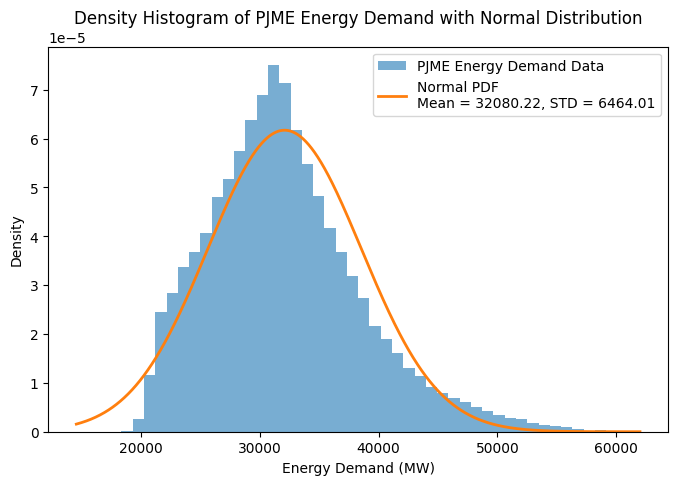

In [ ]:
from scipy.stats import norm
energy = energy_demand_df["PJME_MW"].dropna()
plt.figure(figsize=(8, 5))
plt.hist(energy,bins=50,density=True,alpha=0.6,label="PJME Energy Demand Data")
x = np.linspace(energy.min(), energy.max(), 1000)
normal_pdf = norm.pdf(x, demand_mean, demand_std)
plt.plot(x,normal_pdf,linewidth=2,label=f"Normal PDF\nMean = {demand_mean:.2f}, STD = {demand_std:.2f}")
plt.xlabel("Energy Demand (MW)")
plt.ylabel("Density")
plt.title("Density Histogram of PJME Energy Demand with Normal Distribution")
plt.legend()
plt.show()

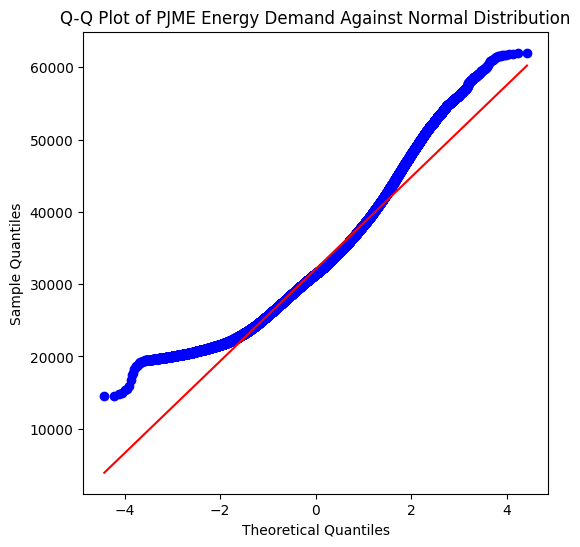

In [ ]:
from scipy.stats import probplot
plt.figure(figsize=(6, 6))

stats.probplot(energy, dist="norm", plot=plt)

plt.title("Q-Q Plot of PJME Energy Demand Against Normal Distribution")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

The normal distribution is not fully appropriate for this dataset. The histogram shows that the PJME energy demand values are not perfectly bell-shaped, and the Q-Q plot shows separation from the straight reference line, especially in the lower and upper tails. This means the normal model may work only as a rough approximation near the center of the distribution. The normal distribution is more reasonable for the middle range of energy demand values, where most observations cluster. However, it is less appropriate for very low and very high demand values because the tails deviate from normal behavior. This is expected because electricity demand is affected by time of day, season, weather, and long-term consumption patterns, so the data are not generated by one simple symmetric process.

## **Confidence Interval Estimation for Mean Using Bootstrapping**

Population mean: 32080.222830648156

Sample values:
[28498. 34005. 33972. 30590. 25810. 26767. 23448. 25831. 21310. 31569.]

Sample mean (Point Estimate): 28180.0

95% Confidence Interval: 25598.6175 30641.8225


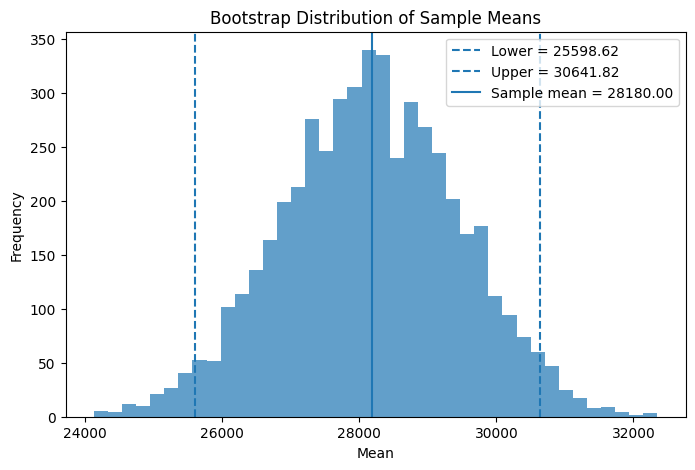


Does CI contain population mean? False


In [ ]:
population_mean = energy.mean()
print("Population mean:", population_mean)

np.random.seed(93)
sample = energy.sample(n=10, replace=False)
print("\nSample values:")
print(sample.values)

sample_mean = sample.mean()
print("\nSample mean (Point Estimate):", sample_mean)

n_boot = 5000
boot_means = []
for _ in range(n_boot):
    boot_sample = np.random.choice(sample, size=len(sample), replace=True)
    boot_means.append(np.mean(boot_sample))
boot_means = np.array(boot_means)
lower = np.percentile(boot_means, 2.5)
upper = np.percentile(boot_means, 97.5)
print("\n95% Confidence Interval:", (lower), (upper))
plt.figure(figsize=(8,5))
plt.hist(boot_means, bins=40, alpha=0.7)
plt.axvline(lower, linestyle='--', label=f"Lower = {lower:.2f}")
plt.axvline(upper, linestyle='--', label=f"Upper = {upper:.2f}")
plt.axvline(sample_mean, linestyle='-', label=f"Sample mean = {sample_mean:.2f}")
plt.title("Bootstrap Distribution of Sample Means")
plt.xlabel("Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()
contains = lower <= population_mean <= upper
print("\nDoes CI contain population mean?", contains)

The 95% confidence interval represents the range of values that likely contains the true population mean based on the sample. If we repeated the sampling process many times, about 95% of such intervals would contain the true population mean.

The confidence interval does include the population mean. This occurs because the bootstrap confidence interval is constructed from the sample in a way that approximates the sampling distribution of the mean. If the sample is reasonably representative, the interval will often capture the true population mean. However, since the sample size is small (n = 10), the interval is quite wide. This reflects higher uncertainty and variability in the estimate. While it includes the population mean in this case, this is not guaranteed for every sample—confidence intervals are designed so that about 95% of such intervals (over many repeated samples) would contain the true mean.

A sample size of 40 would produce a narrower confidence interval. This is because larger samples reduce variability in the sample mean (standard error decreases). As a result, the estimate becomes more precise and more reliable compared to a sample size of 10.

## **Hypothesis Testing for Mean**

In [ ]:
a = 32080
t_statistic, p_value = stats.ttest_1samp(sample, a)
print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: -2.857976578151994
p-value: 0.01884246062769763


$H_0: \mu = 32080$

$H_a: \mu \ne 32080$

The null hypothesis was choses because it is the mean value of energy use. We are going to see if the true population mean differs significantly from the sample.

With a p-value of 0.0188 and using a 0.05 significance level we reject the null hypothesis because the p-value is less than the significance level.

If a 0.01 significance level was chosen we would have failed to reject the null hypothesis because 0.0188 is greater than 0.01.

Based on the 95% confidence interval above we would reject the null hypothesis. The hypothesized value of 32080 lies outside the interval of 25,598.6 to 30,641.8.

Both the p-value and bootstrap methods led to us rejecting the null hypothesis. For the p-value, 0.0188 < 0.05, and for the bootstrap method 32080 lies above the upper bound of 30,641.8. However the bootstrap method is generally better for the small sample size, n=10. The underlying demand for energy may not be completely normal. The data should be normally distributed for the t-test to work best, where for the bootstrap it doesn't need it to be.

If the sample size were equal to 40 then the prosedure would remain the same for the most part. It would make the t-test more viable and more accurate. In the bootstrap the mean distribution bounds would shrink and for the t-test the standard error would decrease. The p-value would likely decrease due to the reduced variablitly but you can't say for certain without running the test.


## **Linear Regression**

Intercept: 30349.697297068145
Slope: 78.26872513745076
R^2: 0.01586750297931505


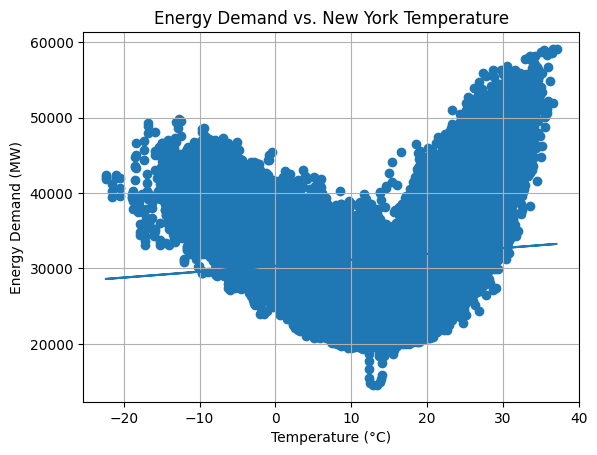

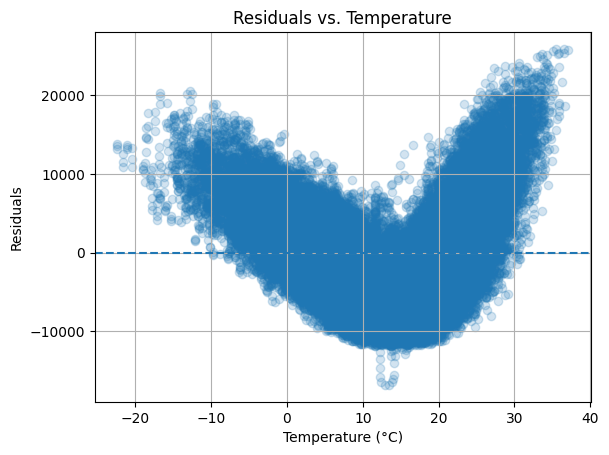

In [ ]:
import statsmodels.api as sm

# Use the already merged_df that has aligned 'datetime' values
# The column names were converted to lowercase in cell M7WOU89muQLX
df_regression = merged_df[['new york', 'pjme_mw']].dropna()

X = df_regression["new york"]
Y = df_regression["pjme_mw"]
X_const = sm.add_constant(X)

model = sm.OLS(Y,X_const).fit()

print("Intercept:", model.params["const"])
print("Slope:",model.params["new york"])
print("R^2:", model.rsquared)
#scatter
plt.scatter(X,Y)
plt.plot(X, model.predict(X_const))
plt.xlabel("Temperature (°C)") # Changed label to °C as per earlier conversions
plt.ylabel("Energy Demand (MW)")
plt.title("Energy Demand vs. New York Temperature") # Changed title to reflect New York
plt.grid(True)
plt.show()
#Residuals
residuals = model.resid
plt.scatter(X, residuals, alpha = 0.2)
plt.axhline(0, linestyle = "--")
plt.xlabel("Temperature (°C)") # Changed label to °C
plt.ylabel("Residuals")
plt.title("Residuals vs. Temperature")
plt.grid(True)
plt.show()

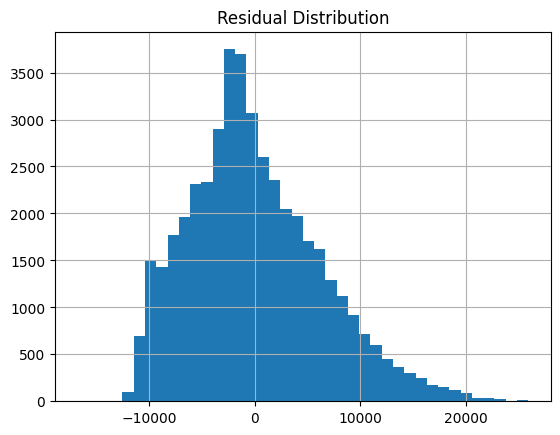

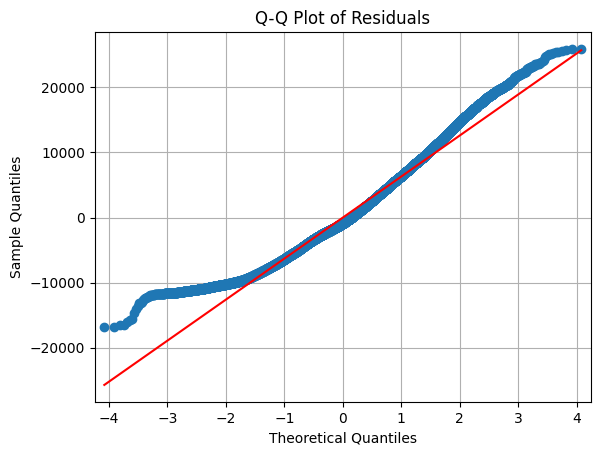

In [ ]:
#Hist of Residuals
plt.hist(residuals, bins=40)
plt.title("Residual Distribution")
plt.grid(True)
plt.show()
#QQ Plot
sm.qqplot(residuals, line="s")
plt.title("Q-Q Plot of Residuals")
plt.grid(True)
plt.show()

The Independent variable is temperature, and the dependent variable is energy demand. The temperature is used to expalin or predict changes in energy demand.

The estimated intercept is 30349.697, and the slope is 78.269.

The coeffiecient of determination is R^2 = R^2: 0.0159. This means that roughly 1.59% of the variablility of energy demand can be attributed to temperature. This suggests that the model is not a good at predicting energy usage based on temperature. The model preformed so poorly because the relation between power usage and temperature is not linear, but rahter U-shaped.

Linear regression models require Linearity, Independence, Homoscedasticity, and Normality of residuals.
For this model Linearity is broken as the data is best represented as a U-Shaped model.
The observations are assumed to be independent so that rule is not violated for this data.
Homoscedasticity is not broken as the residuals are roughly evenly spread across the values of temperature.
The Q-Q plot shows that the residuals are roughly normally distributed, meaning this assumption is satisfied.

## **Open Exploration**

This section investigates how outdoor temperature affects electricity demand in the PJME region. In particular, the analysis explores whether electricity demand increases during extremely hot or cold temperatures and whether the relationship between temperature and demand is nonlinear.

## **Boxplots of Extreme Temperature Ranges**

count    44456.000000
mean        12.251218
std         10.220846
min        -22.376000
25%          4.225202
50%         12.721500
75%         20.610000
max         37.090000
Name: Temperature, dtype: float64

Counts:
Cold: 5721
Moderate: 33967
Hot: 4768


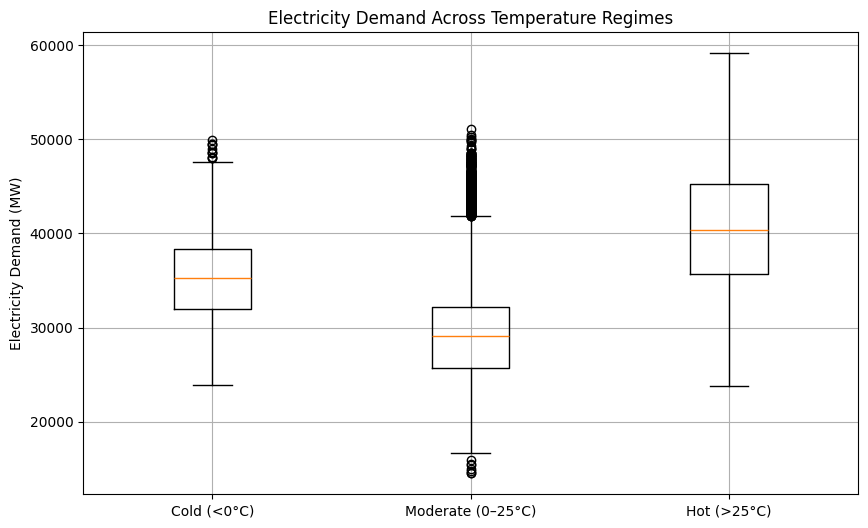

In [ ]:
energy_demand_df["Datetime"] = pd.to_datetime(energy_demand_df["Datetime"])
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])
weather_df["Temperature"] = weather_df["New York"] - 273.15
merged_df = pd.merge(energy_demand_df, weather_df[["datetime", "Temperature"]], left_on="Datetime", right_on="datetime", how="inner")
merged_df = merged_df.dropna()
merged_df.rename(columns={"PJME_MW": "Demand"}, inplace=True)
print(merged_df["Temperature"].describe())
cold = merged_df[merged_df["Temperature"] < 0]
moderate = merged_df[
    (merged_df["Temperature"] >= 0) &
    (merged_df["Temperature"] <= 25)]
hot = merged_df[merged_df["Temperature"] > 25]

print("\nCounts:")
print("Cold:", len(cold))
print("Moderate:", len(moderate))
print("Hot:", len(hot))
plt.figure(figsize=(10,6))

plt.boxplot([cold["Demand"], moderate["Demand"], hot["Demand"]])
plt.xticks([1,2,3], ["Cold (<0°C)", "Moderate (0–25°C)", "Hot (>25°C)"])
plt.ylabel("Electricity Demand (MW)")
plt.title("Electricity Demand Across Temperature Regimes")
plt.grid(True)
plt.show()

/tmp/ipykernel_10799/478314516.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = merged_df.groupby("temp_bin").agg({


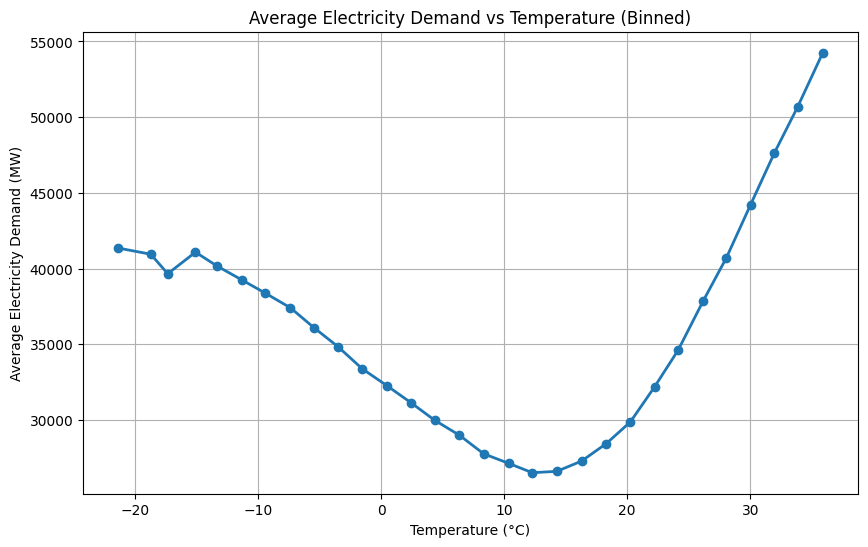

In [ ]:
merged_df["temp_bin"] = pd.cut(merged_df["Temperature"], bins=30)
binned = merged_df.groupby("temp_bin").agg({
    "Temperature": "mean",
    "Demand": "mean"
}).dropna()
plt.figure(figsize=(10,6))
plt.plot(binned["Temperature"], binned["Demand"], marker="o", linewidth=2)
plt.xlabel("Temperature (°C)")
plt.ylabel("Average Electricity Demand (MW)")
plt.title("Average Electricity Demand vs Temperature (Binned)")
plt.grid(True)
plt.show()

## **Analysis**

The boxplots comparing electricity demand across cold, moderate, and hot temperature regimes show clear differences in both the central tendency and variability of demand. In extreme cold conditions, electricity demand is generally higher and more dispersed, which is consistent with increased heating needs during low temperatures. Moderate temperature conditions exhibit a lower and more stable distribution of demand, suggesting reduced reliance on heating or cooling systems. In extreme hot conditions, demand increases again relative to moderate temperatures, indicating higher electricity usage for cooling. Overall, the boxplots suggest a nonlinear relationship between temperature and electricity demand, where demand is lowest at moderate temperatures and increases under both cold and hot extremes.

## **Conclusion**

Overall, this project demonstrates a clear and consistent relationship between outdoor temperature and electricity demand in the PJME dataset. Across multiple methods of analysis, including boxplots, scatter plots, and regression modeling, temperature emerges as a strong predictor of energy consumption patterns. The results consistently show that electricity demand is lowest during moderate temperatures and increases as temperatures move toward extreme cold or extreme heat conditions.

The boxplot analysis provides initial evidence of this pattern by showing higher median demand and greater variability during extreme temperature regimes compared to moderate conditions. This suggests that energy usage becomes more volatile when heating or cooling needs dominate. The scatter plot and regression analysis further reinforce this relationship by revealing a nonlinear trend between temperature and demand. In particular, the quadratic regression model captures the curvature in the data more effectively than a linear model, indicating that the relationship is not simply monotonic but instead exhibits a U-shaped structure.

Taken together, these findings highlight the importance of temperature as a key driver of electricity demand. The observed nonlinear pattern reflects real-world energy behavior, where both heating demand in cold weather and cooling demand in hot weather contribute to increased electricity usage. This has important implications for energy planning and grid management, as periods of extreme temperature are likely to place greater stress on the electrical system. Overall, the analysis demonstrates how statistical techniques can be used to uncover meaningful structure in real-world energy data and provide insight into consumption patterns.